# VWAP and TWAP Execution Algorithms

**Docker image**: `ml4t`

This notebook implements the two most common execution benchmarks:

- **TWAP (Time-Weighted Average Price)**: Equal slices over time
- **VWAP (Volume-Weighted Average Price)**: Slices proportional to expected volume

**Learning Objectives**
- Build TWAP and VWAP schedules from execution constraints and volume forecasts
- Simulate realized execution prices against a benchmark VWAP path
- Quantify when VWAP improves benchmark tracking relative to TWAP
- Translate schedule shapes into practical execution guidance

**Book Reference:** Chapter 18: Section 18.5 (Execution Algorithms as Controls)

**Prerequisites:** Read [`03_market_impact_calibration`](03_market_impact_calibration.ipynb) for impact assumptions
and [`05_almgren_chriss_optimal_execution`](05_almgren_chriss_optimal_execution.ipynb) for the transition from control
algorithms to explicit cost-risk optimization.

## Why TWAP and VWAP?

These algorithms serve as:
- **Execution benchmarks**: Performance measured vs VWAP
- **Risk minimization**: Spread execution to reduce timing risk
- **Market impact control**: Avoid moving markets with large orders
- **Passive strategies**: Execute without alpha view

| Algorithm | Best For | Key Assumption |
|-----------|----------|----------------|
| TWAP | Illiquid stocks, stable volume | Volume is unpredictable |
| VWAP | Liquid stocks, predictable patterns | Historical volume predicts intraday |

## Imports & Settings

In [1]:
"""VWAP and TWAP Execution - Algorithm implementation and evaluation on real NASDAQ-100 sessions."""

import warnings
from datetime import datetime, timedelta

warnings.filterwarnings("ignore")

import numpy as np
import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

import utils  # noqa: F401
from data import load_nasdaq100_bars
from utils.reproducibility import set_global_seeds

In [2]:
# Real AlgoSeek NASDAQ-100 minute bars drive both the volume profile and the
# execution evaluation. The intraday volume forecast is estimated on one window
# and execution is evaluated on a disjoint window so the VWAP forecast is
# strictly out-of-sample.
EXEC_SYMBOLS = ["AAPL", "MSFT", "AMZN", "GOOGL", "META"]  # liquid NASDAQ-100 names
TAQ_START_DATE = "2021-10-01"
TAQ_END_DATE = "2021-12-31"
INTERVAL_MINUTES = 15  # execution grid; 09:30-16:00 → 26 intervals
PROFILE_SPLIT = 0.5  # first fraction of sessions estimates the volume profile
ORDER_SHARES = 100_000
IMPACT_BPS = 5.0  # square-root impact coefficient (see 03_market_impact_calibration)
SEED = 42

In [3]:
set_global_seeds(SEED)

## Part 1: TWAP Algorithm

**TWAP** divides the order equally across time intervals:

$$\text{Trade Size}_t = \frac{\text{Total Order}}{\text{Number of Intervals}}$$

Advantages:
- Simple to implement
- No volume prediction needed
- Works well for illiquid stocks

Disadvantages:
- Ignores intraday volume patterns
- May execute at low-volume times (higher impact)

In [4]:
def build_time_grid(
    start_time: datetime,
    end_time: datetime,
    interval_minutes: int,
) -> list[datetime]:
    """Create the execution clock used by both TWAP and VWAP.

    Each returned timestamp is a *decision time* — the instant a slice is
    scheduled — not the boundary of a closed time interval. Slice volume is
    attributed to the interval beginning at that decision time.
    """
    current = start_time
    times = []
    while current <= end_time:
        times.append(current)
        current += timedelta(minutes=interval_minutes)
    return times

### Build the TWAP Share Schedule

In [5]:
def build_twap_schedule(
    total_shares: int,
    start_time: datetime,
    end_time: datetime,
    interval_minutes: int,
) -> pl.DataFrame:
    """Allocate shares evenly across the available execution intervals."""
    times = build_time_grid(start_time, end_time, interval_minutes)
    n_intervals = len(times)
    shares_per_interval = total_shares // n_intervals
    remainder = total_shares % n_intervals

    schedule = []
    cumulative = 0
    for i, ts in enumerate(times):
        shares = shares_per_interval + (1 if i < remainder else 0)
        cumulative += shares
        schedule.append(
            {
                "time": ts,
                "shares": shares,
                "cumulative": cumulative,
                "pct_complete": cumulative / total_shares,
            }
        )

    return pl.DataFrame(schedule)

### Target Lookup Helper

In [6]:
def latest_cumulative_target(schedule: pl.DataFrame, current_time: datetime) -> int:
    """Return the most recent cumulative target in the schedule."""
    mask = schedule["time"].to_numpy() <= current_time
    if not mask.any():
        return 0
    return schedule["cumulative"][np.where(mask)[0][-1]]

### TWAP Summary Helper

In [7]:
def summarize_twap(algo) -> dict:
    """Create a compact TWAP schedule summary."""
    return {
        "algorithm": "TWAP",
        "total_shares": algo.total_shares,
        "n_intervals": len(algo.schedule),
        "interval_minutes": algo.interval_minutes,
        "shares_per_interval": algo.total_shares // len(algo.schedule),
    }

### TWAP Class Definition

In [8]:
class TWAPAlgorithm:
    """Time-Weighted Average Price execution algorithm."""

    def __init__(
        self, total_shares: int, start_time: datetime, end_time: datetime, interval_minutes: int = 5
    ):
        self.total_shares = total_shares
        self.start_time = start_time
        self.end_time = end_time
        self.interval_minutes = interval_minutes
        self.schedule = build_twap_schedule(
            total_shares=self.total_shares,
            start_time=self.start_time,
            end_time=self.end_time,
            interval_minutes=self.interval_minutes,
        )

    def get_target_at_time(self, current_time: datetime) -> int:
        return latest_cumulative_target(self.schedule, current_time)

    def summary(self) -> dict:
        return summarize_twap(self)

In [9]:
# Example TWAP schedule
start = datetime(2024, 1, 15, 9, 30)
end = datetime(2024, 1, 15, 16, 0)

twap = TWAPAlgorithm(
    total_shares=100_000,
    start_time=start,
    end_time=end,
    interval_minutes=15,
)

print("TWAP Schedule Summary:")
for k, v in twap.summary().items():
    print(f"  {k}: {v}")

twap.schedule.head(10)

TWAP Schedule Summary:
  algorithm: TWAP
  total_shares: 100000
  n_intervals: 27
  interval_minutes: 15
  shares_per_interval: 3703


time,shares,cumulative,pct_complete
datetime[μs],i64,i64,f64
2024-01-15 09:30:00,3704,3704,0.03704
2024-01-15 09:45:00,3704,7408,0.07408
2024-01-15 10:00:00,3704,11112,0.11112
2024-01-15 10:15:00,3704,14816,0.14816
2024-01-15 10:30:00,3704,18520,0.1852
2024-01-15 10:45:00,3704,22224,0.22224
2024-01-15 11:00:00,3704,25928,0.25928
2024-01-15 11:15:00,3704,29632,0.29632
2024-01-15 11:30:00,3704,33336,0.33336


**Finding**: The TWAP summary confirms that the schedule is intentionally blind
to liquidity conditions. Equal slice sizes are a feature when the desk wants
robustness, but they also guarantee trading through the session's thin spots.

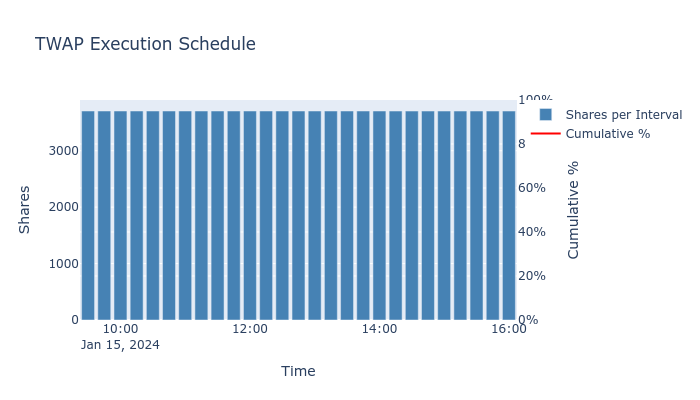

In [10]:
# Visualize TWAP schedule
fig = go.Figure()

times = twap.schedule["time"].to_list()
shares = twap.schedule["shares"].to_list()
cumulative = twap.schedule["cumulative"].to_list()

fig.add_bar(
    x=times,
    y=shares,
    name="Shares per Interval",
    marker_color="steelblue",
)

fig.add_scatter(
    x=times,
    y=[c / twap.total_shares * max(shares) for c in cumulative],
    mode="lines",
    name="Cumulative %",
    yaxis="y2",
    line=dict(color="red", width=2),
)

fig.update_layout(
    title="TWAP Execution Schedule",
    xaxis_title="Time",
    yaxis_title="Shares",
    yaxis2=dict(
        title="Cumulative %",
        overlaying="y",
        side="right",
        tickformat=".0%",
        range=[0, 1],
    ),
    height=400,
)
fig.show()

**Finding**: TWAP creates a flat schedule in share space and a linear ramp in
cumulative completion. That makes the algorithm robust when volume forecasts are
unreliable, but it also guarantees activity during the midday liquidity trough.

## Part 2: VWAP Algorithm

**VWAP** matches the market's volume profile:

$$\text{Trade Size}_t = \text{Total Order} \times \frac{\text{Expected Volume}_t}{\text{Total Expected Volume}}$$

Advantages:
- Reduces impact by trading when liquidity is high
- Better benchmark tracking
- Industry standard for passive execution

Disadvantages:
- Requires volume prediction
- May front-run predictable patterns

### Intraday Volume Patterns from Real Minute Bars

US equity markets exhibit a consistent **U-shaped** volume pattern — high at the
open, thin at midday, high into the close. Rather than assume that shape, we
measure it directly from AlgoSeek NASDAQ-100 minute bars and use the measured
profile as the VWAP volume forecast. We restrict to the regular session
(09:30-16:00) and aggregate minute bars onto the execution grid.

In [11]:
def load_intraday_panel(
    symbols: list[str],
    start_date: str,
    end_date: str,
    interval_minutes: int,
) -> pl.DataFrame:
    """Aggregate real minute bars onto an intraday execution grid.

    Returns per (symbol, date, bucket) the interval volume and the
    volume-weighted trade price. Buckets index the regular-session intervals
    from the open (bucket 0 = 09:30) at ``interval_minutes`` granularity.
    """
    session_start = 9 * 60 + 30  # 09:30 as minute-of-day
    session_end = 16 * 60  # 16:00
    panel = (
        load_nasdaq100_bars(
            start_date=start_date,
            end_date=end_date,
            include_microstructure=True,
            lazy=True,
        )
        .filter(pl.col("symbol").is_in(symbols))
        .select("timestamp", "symbol", "volume", "last_trade_price")
        .filter(pl.col("last_trade_price").is_not_null() & (pl.col("volume") > 0))
        .with_columns(
            date=pl.col("timestamp").dt.date(),
            minute_of_day=pl.col("timestamp").dt.hour().cast(pl.Int32) * 60
            + pl.col("timestamp").dt.minute().cast(pl.Int32),
        )
        .filter(
            (pl.col("minute_of_day") >= session_start) & (pl.col("minute_of_day") < session_end)
        )
        .with_columns(
            bucket=((pl.col("minute_of_day") - session_start) // interval_minutes).cast(pl.Int32)
        )
        .group_by("symbol", "date", "bucket")
        .agg(
            volume=pl.col("volume").sum(),
            price=(pl.col("last_trade_price") * pl.col("volume")).sum() / pl.col("volume").sum(),
        )
        .sort("symbol", "date", "bucket")
        .collect()
    )
    return panel

In [12]:
N_BUCKETS = (16 * 60 - (9 * 60 + 30)) // INTERVAL_MINUTES
panel = load_intraday_panel(EXEC_SYMBOLS, TAQ_START_DATE, TAQ_END_DATE, INTERVAL_MINUTES)
print(
    f"Loaded {panel.height:,} interval rows for {panel['symbol'].n_unique()} symbols "
    f"across {panel['date'].n_unique()} sessions ({N_BUCKETS} intervals per session)"
)

Loaded 6,656 interval rows for 4 symbols across 64 sessions (26 intervals per session)


### Extract Per-Day Price and Volume Paths

Keep only sessions with full interval coverage so each day yields aligned
price and volume arrays of length `N_BUCKETS`.

In [13]:
def day_paths(panel: pl.DataFrame, symbol: str, n_buckets: int) -> dict:
    """Return {date: (price_path, volume_path)} for fully covered sessions."""
    sym = panel.filter(pl.col("symbol") == symbol).sort("date", "bucket")
    out = {}
    for d in sym["date"].unique().to_list():
        g = sym.filter(pl.col("date") == d)
        if g.height == n_buckets:
            out[d] = (g["price"].to_numpy(), g["volume"].to_numpy())
    return out

In [14]:
# Split sessions into a profile-estimation window and a disjoint execution window
# so the VWAP volume forecast is strictly out-of-sample. The panel loads several
# liquid names for context, but the execution study itself profiles and runs a
# single symbol (the first, AAPL) so the schedule and impact numbers refer to one
# instrument; extending it to a per-symbol study would aggregate over all of
# EXEC_SYMBOLS.
profile_symbol = EXEC_SYMBOLS[0]
paths_by_day = day_paths(panel, profile_symbol, N_BUCKETS)
all_days = sorted(paths_by_day)
split_idx = int(len(all_days) * PROFILE_SPLIT)
estimation_days = all_days[:split_idx]
execution_days = all_days[split_idx:]

volume_matrix = np.vstack([paths_by_day[d][1] / paths_by_day[d][1].sum() for d in estimation_days])
base_curve = volume_matrix.mean(axis=0)
base_curve = base_curve / base_curve.sum()
print(
    f"{profile_symbol}: {len(estimation_days)} estimation sessions, "
    f"{len(execution_days)} execution sessions"
)

AAPL: 32 estimation sessions, 32 execution sessions


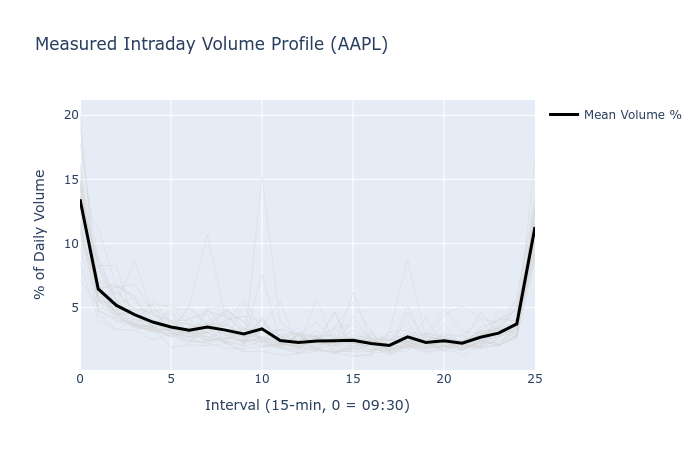

In [15]:
# Plot the measured average profile against the actual per-day realizations.
fig = go.Figure()
bucket_idx = np.arange(N_BUCKETS)
for d in estimation_days:
    daily = paths_by_day[d][1] / paths_by_day[d][1].sum()
    fig.add_scatter(
        x=bucket_idx,
        y=daily * 100,
        mode="lines",
        line=dict(width=1, color="lightgray"),
        opacity=0.4,
        showlegend=False,
    )
fig.add_scatter(
    x=bucket_idx,
    y=base_curve * 100,
    mode="lines",
    name="Mean Volume %",
    line=dict(color="black", width=3),
)
fig.update_layout(
    title=f"Measured Intraday Volume Profile ({profile_symbol})",
    xaxis_title=f"Interval ({INTERVAL_MINUTES}-min, 0 = 09:30)",
    yaxis_title="% of Daily Volume",
    height=450,
)
fig.show()

In [16]:
open_share = base_curve[: max(1, N_BUCKETS // 6)].sum()
midday_share = base_curve[N_BUCKETS // 3 : 2 * N_BUCKETS // 3].sum()
close_share = base_curve[-max(1, N_BUCKETS // 6) :].sum()
print(f"Open hour:   {open_share:.1%} of volume")
print(f"Midday:      {midday_share:.1%} of volume")
print(f"Close hour:  {close_share:.1%} of volume")

Open hour:   29.6% of volume
Midday:      23.8% of volume
Close hour:  20.7% of volume


**Finding**: The measured profile concentrates volume near the open and close
and thins out midday — the empirical U-shape, not an assumed one. The spread of
the faint per-day lines around the mean is the real day-to-day forecast
uncertainty a VWAP desk faces; it is wider than any smooth parametric curve
would suggest, which is exactly why VWAP tracking is imperfect in practice.

### Volume-Curve Alignment Helper

Resamples any input volume curve onto the execution grid so that VWAP
schedules can consume forecasts at arbitrary granularity.

In [17]:
def normalize_volume_curve(volume_curve: np.ndarray, n_intervals: int) -> np.ndarray:
    """Match any input curve to the target execution grid."""
    if len(volume_curve) == n_intervals:
        return volume_curve

    aligned_curve = np.interp(
        np.linspace(0, 1, n_intervals),
        np.linspace(0, 1, len(volume_curve)),
        volume_curve,
    )
    return aligned_curve / aligned_curve.sum()

### Convert a Volume Curve into an Execution Schedule

In [18]:
def build_vwap_schedule(
    total_shares: int,
    start_time: datetime,
    end_time: datetime,
    interval_minutes: int,
    volume_curve: np.ndarray,
) -> pl.DataFrame:
    """Allocate shares in proportion to the expected intraday volume profile."""
    times = build_time_grid(start_time, end_time, interval_minutes)
    n_intervals = len(times)
    shares_float = total_shares * volume_curve[:n_intervals]
    shares_int = np.floor(shares_float).astype(int)

    remainder = total_shares - shares_int.sum()
    if remainder > 0:
        fractions = shares_float - shares_int
        top_idx = np.argsort(fractions)[-int(remainder) :]
        shares_int[top_idx] += 1

    cumulative = np.cumsum(shares_int)
    return pl.DataFrame(
        {
            "time": times,
            "shares": shares_int,
            "volume_weight": volume_curve[:n_intervals],
            "cumulative": cumulative,
            "pct_complete": cumulative / total_shares,
        }
    )

### VWAP Summary Helper

In [19]:
def summarize_vwap(algo) -> dict:
    """Create a compact VWAP schedule summary."""
    return {
        "algorithm": "VWAP",
        "total_shares": algo.total_shares,
        "n_intervals": len(algo.schedule),
        "interval_minutes": algo.interval_minutes,
        "max_shares_interval": algo.schedule["shares"].max(),
        "min_shares_interval": algo.schedule["shares"].min(),
    }

### VWAP Class Definition

In [20]:
class VWAPAlgorithm:
    """Volume-Weighted Average Price execution algorithm."""

    def __init__(
        self,
        total_shares: int,
        start_time: datetime,
        end_time: datetime,
        volume_curve: np.ndarray = None,
        interval_minutes: int = 5,
    ):
        self.total_shares = total_shares
        self.start_time = start_time
        self.end_time = end_time
        self.interval_minutes = interval_minutes
        n_intervals = int((end_time - start_time).total_seconds() / 60 / interval_minutes) + 1
        if volume_curve is None:
            raise ValueError("VWAP requires a measured volume_curve (the empirical profile).")
        self.volume_curve = normalize_volume_curve(volume_curve, n_intervals)
        self.schedule = build_vwap_schedule(
            total_shares=self.total_shares,
            start_time=self.start_time,
            end_time=self.end_time,
            interval_minutes=self.interval_minutes,
            volume_curve=self.volume_curve,
        )

    def get_target_at_time(self, current_time: datetime) -> int:
        return latest_cumulative_target(self.schedule, current_time)

    def summary(self) -> dict:
        return summarize_vwap(self)

In [21]:
# Example VWAP schedule, driven by the measured intraday volume profile
vwap = VWAPAlgorithm(
    total_shares=ORDER_SHARES,
    start_time=start,
    end_time=end,
    volume_curve=base_curve,
    interval_minutes=15,
)

print("VWAP Schedule Summary:")
for k, v in vwap.summary().items():
    print(f"  {k}: {v}")

vwap.schedule.head(10)

VWAP Schedule Summary:
  algorithm: VWAP
  total_shares: 100000
  n_intervals: 27
  interval_minutes: 15
  max_shares_interval: 12954
  min_shares_interval: 2076


time,shares,volume_weight,cumulative,pct_complete
datetime[μs],i64,f64,i64,f64
2024-01-15 09:30:00,12954,0.129542,12954,0.12954
2024-01-15 09:45:00,6487,0.064873,19441,0.19441
2024-01-15 10:00:00,5082,0.050818,24523,0.24523
2024-01-15 10:15:00,4376,0.043757,28899,0.28899
2024-01-15 10:30:00,3827,0.03827,32726,0.32726
2024-01-15 10:45:00,3445,0.034451,36171,0.36171
2024-01-15 11:00:00,3179,0.031786,39350,0.3935
2024-01-15 11:15:00,3297,0.032966,42647,0.42647
2024-01-15 11:30:00,3205,0.032051,45852,0.45852


**Finding**: The VWAP summary is the schedule-level counterpart to the U-curve.
It converts a volume forecast into child-order sizes, which means its quality is
only as good as the forecast feeding it. This example schedule spans the
inclusive 09:30–16:00 grid (one interval more than the `N_BUCKETS` profile) and
is illustrative; the out-of-sample cross-session evaluation below executes on
the `N_BUCKETS` bucket grid.

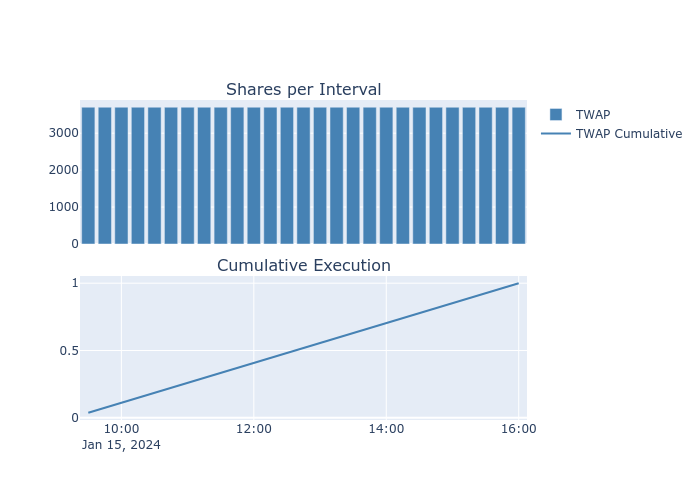

In [22]:
# Compare TWAP vs VWAP schedules
fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    subplot_titles=["Shares per Interval", "Cumulative Execution"],
    vertical_spacing=0.1,
)

# TWAP
twap_times = twap.schedule["time"].to_list()
fig.add_bar(
    x=twap_times,
    y=twap.schedule["shares"].to_list(),
    name="TWAP",
    marker_color="steelblue",
    row=1,
    col=1,
)
fig.add_scatter(
    x=twap_times,
    y=twap.schedule["pct_complete"].to_list(),
    mode="lines",
    name="TWAP Cumulative",
    line=dict(color="steelblue", width=2),
    row=2,
    col=1,
)

#### Add VWAP Schedule Overlay

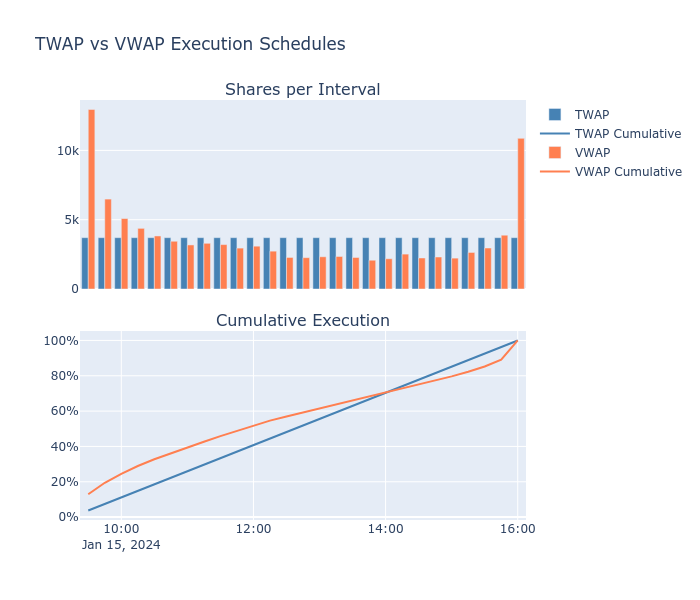

In [23]:
# VWAP
vwap_times = vwap.schedule["time"].to_list()
fig.add_bar(
    x=vwap_times,
    y=vwap.schedule["shares"].to_list(),
    name="VWAP",
    marker_color="coral",
    row=1,
    col=1,
)
fig.add_scatter(
    x=vwap_times,
    y=vwap.schedule["pct_complete"].to_list(),
    mode="lines",
    name="VWAP Cumulative",
    line=dict(color="coral", width=2),
    row=2,
    col=1,
)

fig.update_yaxes(tickformat=".0%", row=2, col=1)
fig.update_layout(
    title="TWAP vs VWAP Execution Schedules",
    height=600,
    barmode="group",
)
fig.show()

**Finding**: VWAP reduces share count in the lunch-hour trough and shifts risk
toward the open and close auctions. Relative to TWAP, it accepts forecast risk
in exchange for lower expected footprint when the market is thin.

## Part 3: Executing Against a Real Trading Day

We now run the TWAP and VWAP schedules against an actual NASDAQ-100 session —
real interval prices and real interval volumes — and measure realized execution
price against that day's market VWAP.

In [24]:
def shares_from_profile(profile: np.ndarray, total_shares: int) -> np.ndarray:
    """Allocate integer shares across intervals in proportion to a profile."""
    raw = total_shares * (profile / profile.sum())
    shares = np.floor(raw).astype(int)
    remainder = total_shares - int(shares.sum())
    if remainder > 0:
        top_idx = np.argsort(raw - shares)[-remainder:]
        shares[top_idx] += 1
    return shares

### Execute a Schedule Against Real Interval Prices and Volumes

Impact uses the interval's **actual market volume** as the participation
denominator under the square-root law: a slice arriving in a high-volume
interval pays less impact than the same slice in the midday lull. This is the
participation-rate edge VWAP is designed to exploit.

In [25]:
def execute_day(
    shares: np.ndarray,
    price_path: np.ndarray,
    volume_path: np.ndarray,
    impact_bps: float,
) -> tuple[float, np.ndarray]:
    """Return (realized VWAP, per-interval execution price) for a share schedule."""
    interval_volume = np.maximum(volume_path.astype(float), 1.0)
    participation = np.sqrt(np.maximum(shares, 0) / interval_volume)
    exec_price = price_path * (1 + impact_bps / 10000 * participation)
    realized_vwap = float((exec_price * shares).sum() / shares.sum())
    return realized_vwap, exec_price


def market_vwap_of(price_path: np.ndarray, volume_path: np.ndarray) -> float:
    """Volume-weighted average price actually traded over the session."""
    return float((price_path * volume_path).sum() / volume_path.sum())

In [26]:
# Build the two schedules on the execution grid and run them against one real day.
twap_shares = shares_from_profile(np.ones(N_BUCKETS), ORDER_SHARES)
vwap_shares = shares_from_profile(base_curve, ORDER_SHARES)

demo_day = execution_days[0]
demo_price, demo_volume = paths_by_day[demo_day]

market_vwap = market_vwap_of(demo_price, demo_volume)
twap_realized, twap_exec_price = execute_day(twap_shares, demo_price, demo_volume, IMPACT_BPS)
vwap_realized, vwap_exec_price = execute_day(vwap_shares, demo_price, demo_volume, IMPACT_BPS)

twap_vs_benchmark = (twap_realized / market_vwap - 1) * 10000
vwap_vs_benchmark = (vwap_realized / market_vwap - 1) * 10000

print(f"Session: {demo_day} ({profile_symbol})")
print("=" * 50)
print(f"Market VWAP:    ${market_vwap:.4f}")
print(f"TWAP Realized:  ${twap_realized:.4f} ({twap_vs_benchmark:+.1f} bps vs VWAP)")
print(f"VWAP Realized:  ${vwap_realized:.4f} ({vwap_vs_benchmark:+.1f} bps vs VWAP)")

Session: 2021-11-16 (AAPL)
Market VWAP:    $150.6400
TWAP Realized:  $150.7784 (+9.2 bps vs VWAP)
VWAP Realized:  $150.6032 (-2.4 bps vs VWAP)


**Finding**: On this real session the benchmark comparison separates schedule
quality from market direction. VWAP tracks the day's market VWAP more closely
because it spends more of the order in the high-volume open and close buckets,
not because it forecasts price direction.

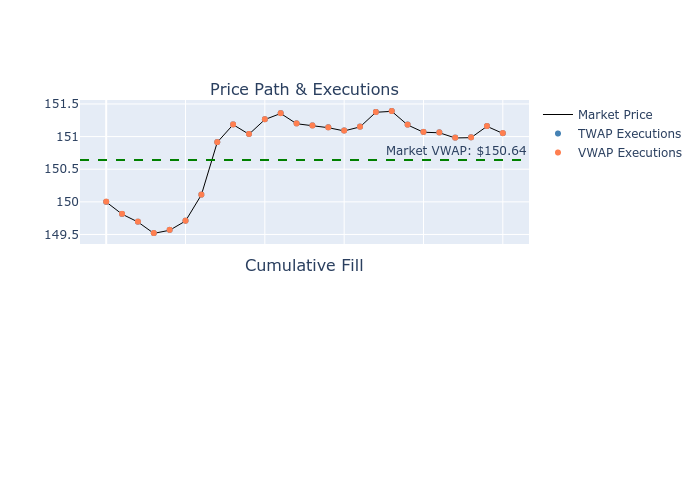

In [27]:
# Visualize execution against the real session
fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    subplot_titles=["Price Path & Executions", "Cumulative Fill"],
    vertical_spacing=0.1,
)

fig.add_scatter(
    x=bucket_idx,
    y=demo_price,
    mode="lines",
    name="Market Price",
    line=dict(color="black", width=1),
    row=1,
    col=1,
)
fig.add_hline(
    y=market_vwap,
    line_dash="dash",
    line_color="green",
    annotation_text=f"Market VWAP: ${market_vwap:.2f}",
    row=1,
    col=1,
)
fig.add_scatter(
    x=bucket_idx,
    y=twap_exec_price,
    mode="markers",
    name="TWAP Executions",
    marker=dict(size=6, color="steelblue"),
    row=1,
    col=1,
)
fig.add_scatter(
    x=bucket_idx,
    y=vwap_exec_price,
    mode="markers",
    name="VWAP Executions",
    marker=dict(size=6, color="coral"),
    row=1,
    col=1,
)

#### Cumulative Fill Comparison

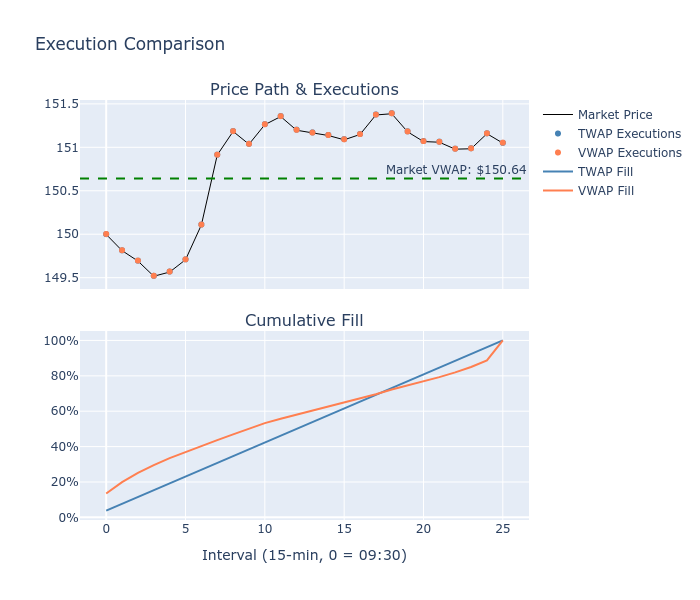

In [28]:
fig.add_scatter(
    x=bucket_idx,
    y=np.cumsum(twap_shares) / ORDER_SHARES,
    mode="lines",
    name="TWAP Fill",
    line=dict(color="steelblue", width=2),
    row=2,
    col=1,
)
fig.add_scatter(
    x=bucket_idx,
    y=np.cumsum(vwap_shares) / ORDER_SHARES,
    mode="lines",
    name="VWAP Fill",
    line=dict(color="coral", width=2),
    row=2,
    col=1,
)
fig.update_xaxes(title_text=f"Interval ({INTERVAL_MINUTES}-min, 0 = 09:30)", row=2, col=1)
fig.update_yaxes(tickformat=".0%", row=2, col=1)
fig.update_layout(title="Execution Comparison", height=600)
fig.show()

**Finding**: VWAP clusters fills around the high-liquidity open and close
buckets and usually lands closer to market VWAP than TWAP. The improvement is
not alpha generation; it is lower benchmark slippage.

## Part 4: Cross-Session Distribution

A single session can favor either schedule by luck. We run both schedules across
every held-out execution session and compare the *distribution* of slippage
versus each day's market VWAP. The volume profile feeding VWAP was estimated on
the earlier window, so this is an out-of-sample test of the forecast.

In [29]:
def run_across_days(
    days: list,
    paths: dict,
    twap_shares: np.ndarray,
    vwap_shares: np.ndarray,
    impact_bps: float,
) -> pl.DataFrame:
    """Execute both schedules on each real session and collect slippage vs VWAP."""
    rows = []
    for d in days:
        price_path, volume_path = paths[d]
        mkt = market_vwap_of(price_path, volume_path)
        twap_realized, _ = execute_day(twap_shares, price_path, volume_path, impact_bps)
        vwap_realized, _ = execute_day(vwap_shares, price_path, volume_path, impact_bps)
        rows.append(
            {
                "date": d,
                "twap_vs_market_bps": (twap_realized / mkt - 1) * 10000,
                "vwap_vs_market_bps": (vwap_realized / mkt - 1) * 10000,
            }
        )
    return pl.DataFrame(rows)

In [30]:
mc_results = run_across_days(execution_days, paths_by_day, twap_shares, vwap_shares, IMPACT_BPS)

print(f"Cross-session results ({mc_results.height} held-out sessions, {profile_symbol})")
print("=" * 50)
print("\nTWAP vs Market VWAP:")
print(f"  Mean: {mc_results['twap_vs_market_bps'].mean():+.2f} bps")
print(f"  Std:  {mc_results['twap_vs_market_bps'].std():.2f} bps")
print(f"  Min:  {mc_results['twap_vs_market_bps'].min():+.2f} bps")
print(f"  Max:  {mc_results['twap_vs_market_bps'].max():+.2f} bps")

print("\nVWAP Algorithm vs Market VWAP:")
print(f"  Mean: {mc_results['vwap_vs_market_bps'].mean():+.2f} bps")
print(f"  Std:  {mc_results['vwap_vs_market_bps'].std():.2f} bps")
print(f"  Min:  {mc_results['vwap_vs_market_bps'].min():+.2f} bps")
print(f"  Max:  {mc_results['vwap_vs_market_bps'].max():+.2f} bps")

Cross-session results (32 held-out sessions, AAPL)

TWAP vs Market VWAP:
  Mean: +0.45 bps
  Std:  15.93 bps
  Min:  -53.22 bps
  Max:  +35.27 bps

VWAP Algorithm vs Market VWAP:
  Mean: -1.81 bps
  Std:  12.30 bps
  Min:  -45.03 bps
  Max:  +23.25 bps


**Finding**: The cross-session distribution matters more than any single day. If
VWAP improves the mean but leaves the tail much worse, the desk is implicitly
paying for forecast error with benchmark variance.

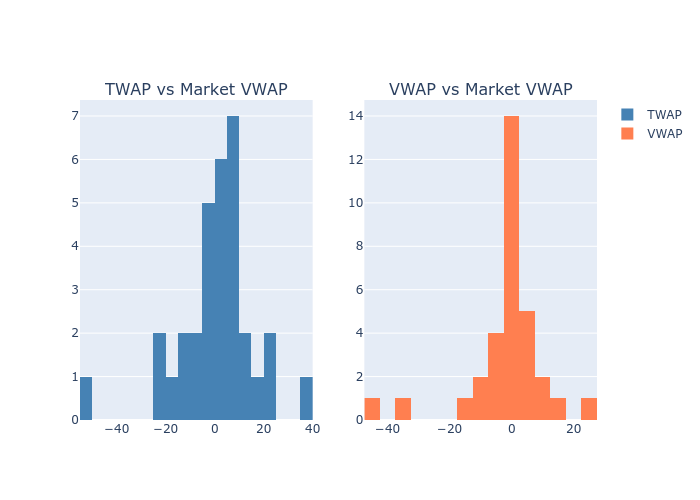

In [31]:
# Visualize results
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=["TWAP vs Market VWAP", "VWAP vs Market VWAP"],
)

fig.add_histogram(
    x=mc_results["twap_vs_market_bps"].to_list(),
    nbinsx=30,
    name="TWAP",
    marker_color="steelblue",
    row=1,
    col=1,
)

fig.add_histogram(
    x=mc_results["vwap_vs_market_bps"].to_list(),
    nbinsx=30,
    name="VWAP",
    marker_color="coral",
    row=1,
    col=2,
)

#### Distribution Mean Markers

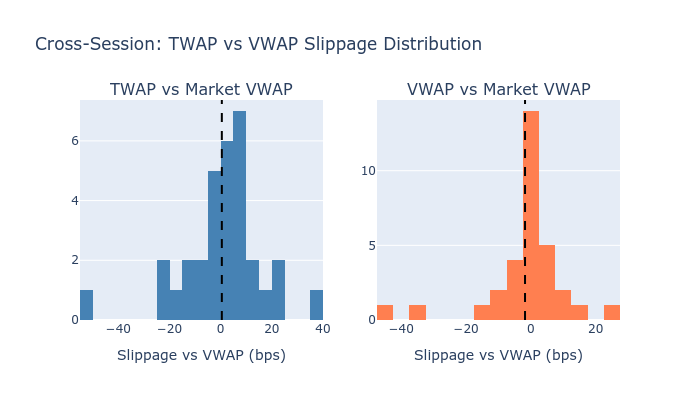

In [32]:
# Add mean lines
twap_mean = mc_results["twap_vs_market_bps"].mean()
vwap_mean = mc_results["vwap_vs_market_bps"].mean()

fig.add_vline(x=twap_mean, line_dash="dash", line_color="black", row=1, col=1)
fig.add_vline(x=vwap_mean, line_dash="dash", line_color="black", row=1, col=2)

fig.update_xaxes(title_text="Slippage vs VWAP (bps)", row=1, col=1)
fig.update_xaxes(title_text="Slippage vs VWAP (bps)", row=1, col=2)
fig.update_layout(
    title="Cross-Session: TWAP vs VWAP Slippage Distribution",
    height=400,
    showlegend=False,
)
fig.show()

**Finding**: The cross-session distribution shows why VWAP is the desk standard
for passive flow. It lowers average slippage versus the benchmark, but the gain
depends on the stability of the intraday volume forecast.

## Part 5: When to Use TWAP vs VWAP

### Use TWAP When:
- Volume patterns are unpredictable
- Stock is illiquid (spreads vary)
- Minimizing timing risk is priority
- Simple, robust execution needed

### Use VWAP When:
- Volume patterns are predictable
- Tracking VWAP benchmark matters
- Stock is liquid with stable patterns
- Reducing market impact is priority

### Hybrid Approaches:
- **Adaptive VWAP**: Update volume predictions intraday
- **Percent of Volume (POV)**: Maintain constant participation rate
- **Implementation Shortfall**: Optimize for IS, not VWAP

In [33]:
# Summary comparison
summary = pl.DataFrame(
    [
        {
            "Metric": "Mean Slippage (bps)",
            "TWAP": f"{mc_results['twap_vs_market_bps'].mean():.2f}",
            "VWAP": f"{mc_results['vwap_vs_market_bps'].mean():.2f}",
        },
        {
            "Metric": "Std Slippage (bps)",
            "TWAP": f"{mc_results['twap_vs_market_bps'].std():.2f}",
            "VWAP": f"{mc_results['vwap_vs_market_bps'].std():.2f}",
        },
        {
            "Metric": "Worst Case (bps)",
            "TWAP": f"{mc_results['twap_vs_market_bps'].max():.2f}",
            "VWAP": f"{mc_results['vwap_vs_market_bps'].max():.2f}",
        },
        {
            "Metric": "Volume Prediction",
            "TWAP": "Not Required",
            "VWAP": "Required",
        },
        {
            "Metric": "Best For",
            "TWAP": "Illiquid, Unpredictable",
            "VWAP": "Liquid, Predictable",
        },
    ]
)
print("TWAP vs VWAP Summary")
summary

TWAP vs VWAP Summary


Metric,TWAP,VWAP
str,str,str
"""Mean Slippage (bps)""","""0.45""","""-1.81"""
"""Std Slippage (bps)""","""15.93""","""12.30"""
"""Worst Case (bps)""","""35.27""","""23.25"""
"""Volume Prediction""","""Not Required""","""Required"""
"""Best For""","""Illiquid, Unpredictable""","""Liquid, Predictable"""


**Key takeaway**: TWAP is the robust default when liquidity forecasts are weak.
VWAP earns its edge only when the intraday volume profile is stable enough to
justify trading more aggressively at the open and close.

## Summary

### Key Concepts

1. **TWAP**: Divide equally over time
   - Simple and robust
   - No volume prediction needed
   - Higher variance vs VWAP benchmark

2. **VWAP**: Match market volume profile
   - Requires accurate volume prediction
   - Much lower variance vs benchmark (more consistent tracking)
   - Industry standard for passive execution

3. **Implementation Details**:
   - Use 5-15 minute intervals
   - Account for market impact
   - Consider order book dynamics

### Practical Tips

- **VWAP is not a "beat the market" strategy** - it's a benchmark
- **Volume prediction quality** determines VWAP effectiveness
- **Combine with IS optimization** for alpha-driven trades

### Next Steps

- `05_almgren_chriss_optimal_execution`: Almgren-Chriss optimal execution
- `08_ml_dynamic_execution`: ML-based adaptive execution

In [34]:
print(f"\nCross-session evaluation complete: {mc_results.height} real sessions")
diff = vwap_mean - twap_mean
lower_slippage = "VWAP" if diff < 0 else "TWAP"
print(
    f"Mean slippage: TWAP {twap_mean:+.1f} bps, VWAP {vwap_mean:+.1f} bps "
    f"({lower_slippage} {abs(diff):.1f} bps lower)"
)
twap_std = mc_results["twap_vs_market_bps"].std()
vwap_std = mc_results["vwap_vs_market_bps"].std()
if min(twap_std, vwap_std) > 0:
    if vwap_std < twap_std:
        consistency = f"(VWAP {twap_std / vwap_std:.1f}x more consistent)"
    else:
        consistency = f"(TWAP {vwap_std / twap_std:.1f}x more consistent)"
else:
    consistency = "(degenerate std)"
print(f"Std slippage:  TWAP {twap_std:.1f} bps, VWAP {vwap_std:.1f} bps {consistency}")


Cross-session evaluation complete: 32 real sessions
Mean slippage: TWAP +0.4 bps, VWAP -1.8 bps (VWAP 2.3 bps lower)
Std slippage:  TWAP 15.9 bps, VWAP 12.3 bps (VWAP 1.3x more consistent)


**Finding**: The cross-session summary is the decision rule. Use VWAP when the
forecasted liquidity pattern is stable enough to justify the extra model risk;
otherwise TWAP remains the safer baseline.

## Key Takeaways

1. **Impact is participation-driven, not share-count-driven**: Because each
   slice's impact scales with $\sqrt{\text{shares}/\text{interval volume}}$,
   VWAP's volume-tracking schedule lowers cost by routing more shares into
   high-liquidity intervals — the mechanism the cross-session test quantifies.

2. **VWAP trades consistency for model risk**: VWAP tracks the market
   benchmark with materially lower variance than TWAP, but only when the
   forecasted intraday volume profile is reliable. A bad volume forecast
   erases the advantage.

3. **Neither algorithm "beats the market"**: TWAP and VWAP are
   benchmark-tracking schedules, not alpha strategies. Choosing between
   them is a risk-management decision about execution-cost variance.

**Next**: `05_almgren_chriss_optimal_execution` derives the cost-variance
optimal trajectory; `08_ml_dynamic_execution` makes the schedule adaptive.